<a href="https://colab.research.google.com/github/Araw-kumar/SmartCart-Segmentation-System/blob/main/SmartCart_Segmentation_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv("smartcart_customers.csv")

In [ ]:
df.head()
# data.info()

# data.shape
# data.isnull().sum()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


# Data Preprocessing

##1. Handle Missing value

In [ ]:
df["Income"]=df["Income"].fillna(df["Income"].median())

In [ ]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,0
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [ ]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


#Feature Engineering

In [ ]:
#Age (as per 2026)
df["Age"]=2026-df["Year_Birth"]


In [ ]:
#Customer_tenure_days
df["Dt_Customer"]=pd.to_datetime(df["Dt_Customer"],dayfirst=True)
reference_date=df["Dt_Customer"].max()
df["Costomer_tenure_days"]=(reference_date -  df["Dt_Customer"]).dt.days

In [ ]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Costomer_tenure_days'],
      dtype='object')

In [ ]:
#spending
df["Total_spending"]=df["MntWines"]+df["MntFruits"]+df["MntMeatProducts"]+df["MntFishProducts"]+df["MntSweetProducts"]+df["MntGoldProds"]

In [ ]:
#Children
df["Total_children"]=df["Kidhome"]+df["Teenhome"]

In [ ]:
#Education
df["Education"].value_counts()

df["Education"]=df["Education"].replace({"2n Cycle":"Undergraduate",
                                         "Basic":"Undergraduate",
                                         "Graduation":"Graduate",
                                         "PhD":"Postgraduate",
                                         "Master":"Postgraduate"})

In [ ]:
df["Education"].value_counts()

,count
Education,
Graduate,1127
Postgraduate,856
Undergraduate,257


In [ ]:
#Marital_status
df["Living_with"]=df["Marital_Status"].replace({
    "Married":"Partner","Together":"Partner",
    "Single":"Alone","Divorced":"Alone","Widow":"Alone","Alone":"Alone","Absurd":"Alone","YOLO":"Alone"
    })

In [ ]:

df["Living_with"].value_counts()

,count
Living_with,
Partner,1444
Alone,796


In [ ]:
df.shape

(2240, 27)

##Drop Columns


In [ ]:
cols=["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer"]
spending_cols=["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]
drop_cols=cols+spending_cols

cleaned_df=df.drop(columns=drop_cols)

In [ ]:
cleaned_df.shape

(2240, 15)

#Outlier detection

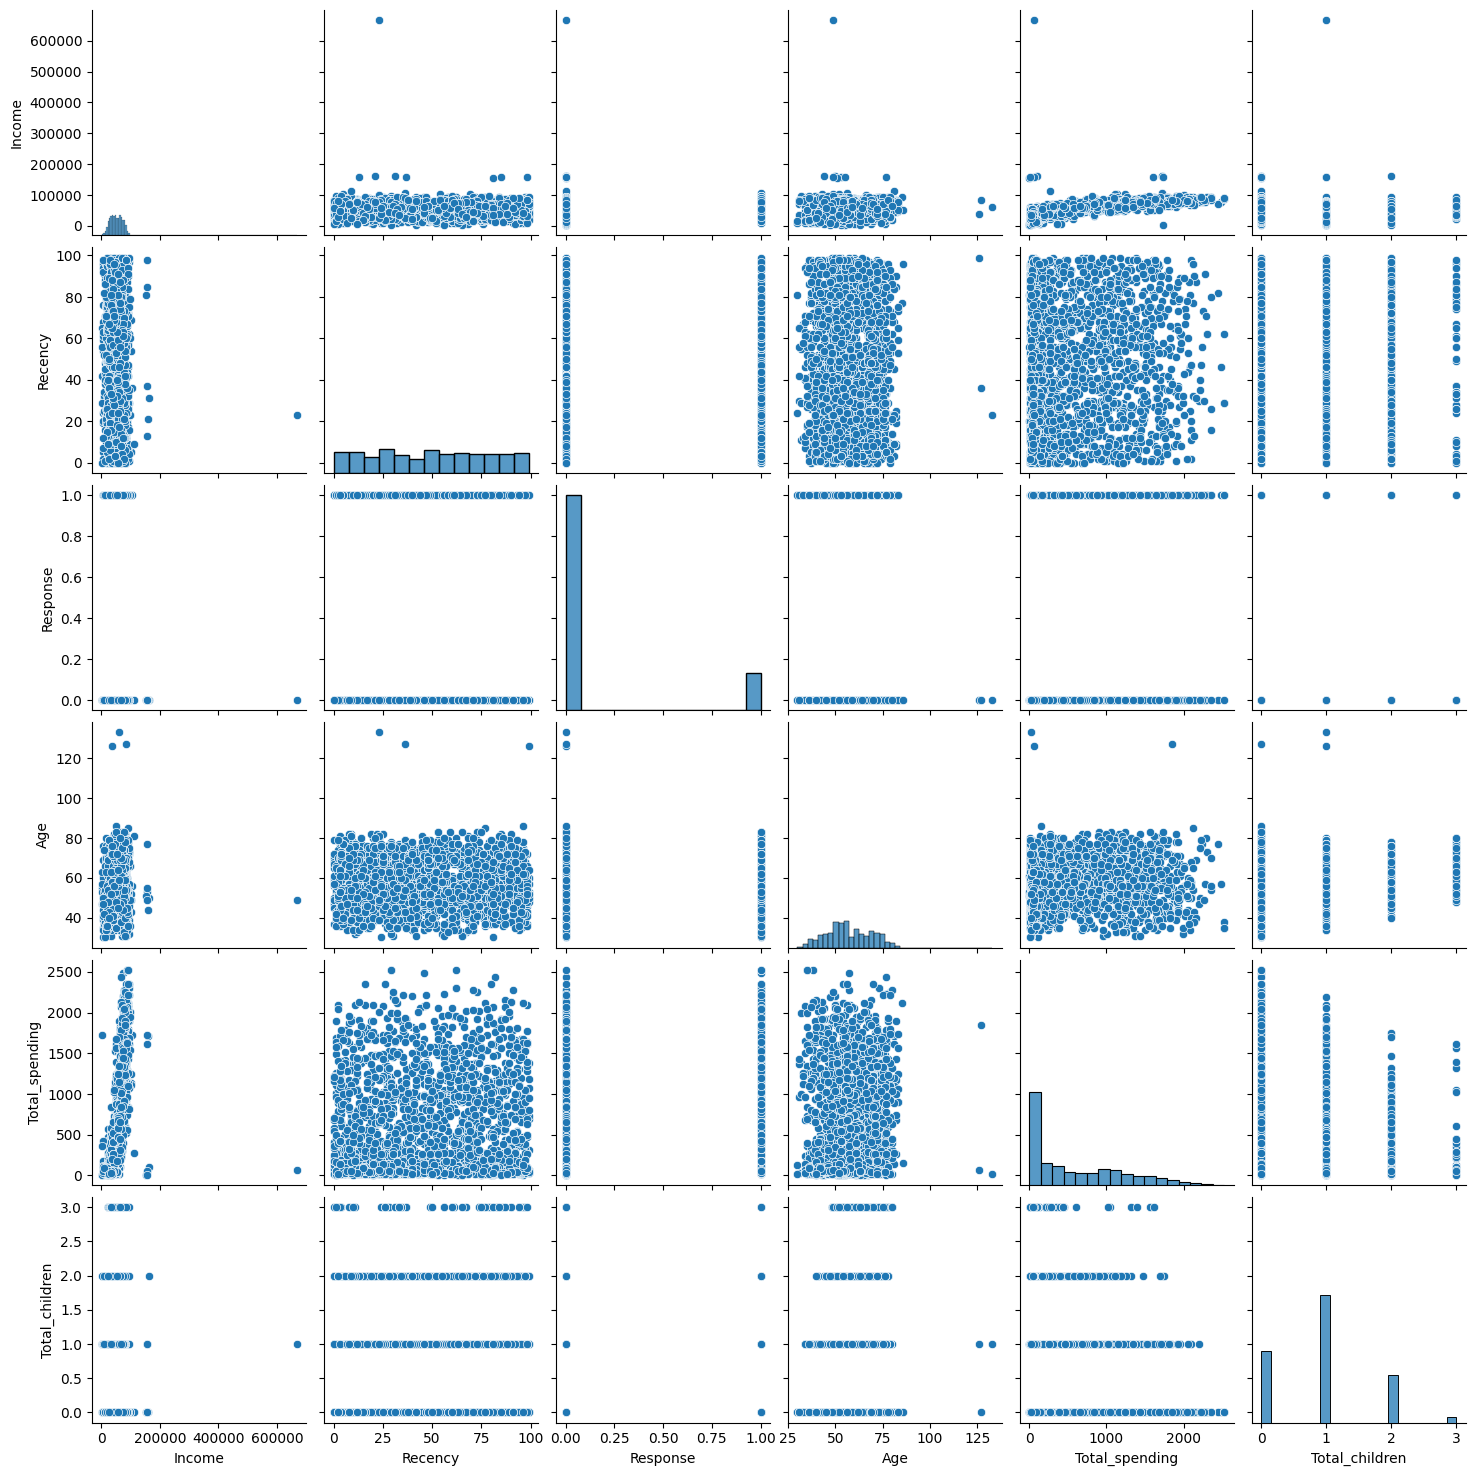

In [ ]:
cols=["Income","Recency","Response","Age","Total_spending","Total_children"]

#design pair plots
sns.pairplot(cleaned_df[cols])

In [ ]:
#Remove Outliers
print("data size with outliers: ",len(cleaned_df))

cleaned_df=cleaned_df[cleaned_df["Age"]<90]
cleaned_df=cleaned_df[cleaned_df["Income"]<600000]

print("data size without outliers: ",len(cleaned_df))


data size with outliers:  2240
data size without outliers:  2236


#Heatmap

<Axes: >

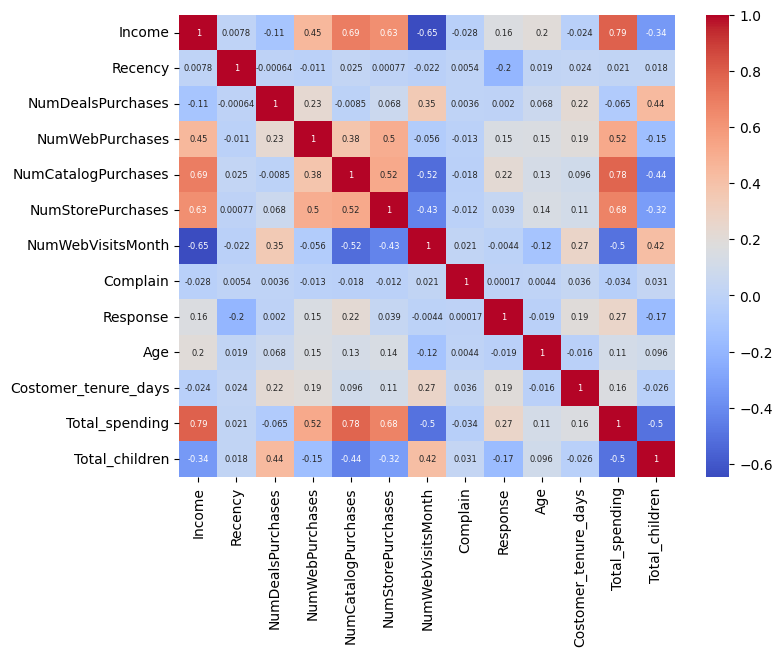

In [ ]:
#correlation matrix
corr=cleaned_df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size":6},#for size
    cmap="coolwarm"
)

#Encoding


In [ ]:
cat_cols=["Education","Living_with"]
from sklearn.preprocessing import OneHotEncoder
ohe=OneHotEncoder()

encode_cols=ohe.fit_transform(cleaned_df[cat_cols])
enco_df=pd.DataFrame(encode_cols.toarray(),columns=ohe.get_feature_names_out(cat_cols), index=cleaned_df.index)

encoded_df=pd.concat([cleaned_df.drop(columns=cat_cols),enco_df], axis=1)

In [ ]:
encoded_df.shape

(2236, 18)

#Scaling

In [ ]:
X=encoded_df
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

#Visualize

In [ ]:
X_scaled.shape

(2236, 18)

In [ ]:
#dimensionality reduction(PCA)
#2D
from sklearn.decomposition import PCA
pca=PCA(n_components=2)

X_pca=pca.fit_transform(X_scaled)


In [ ]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454])

<Axes: >

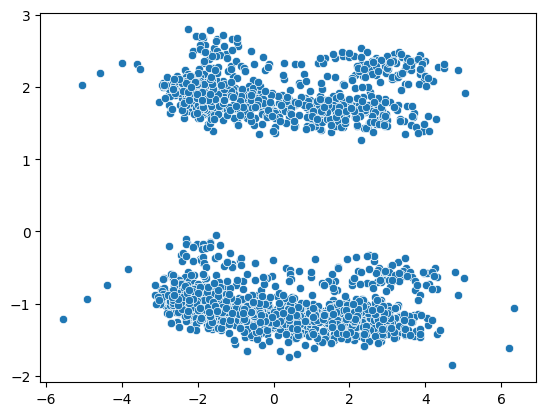

In [ ]:
sns.scatterplot(x=X_pca[:,0],y=X_pca[:,1])

In [ ]:
#3D
pca=PCA(n_components=3)
X_pca=pca.fit_transform(X_scaled)

pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, '3D Projection')

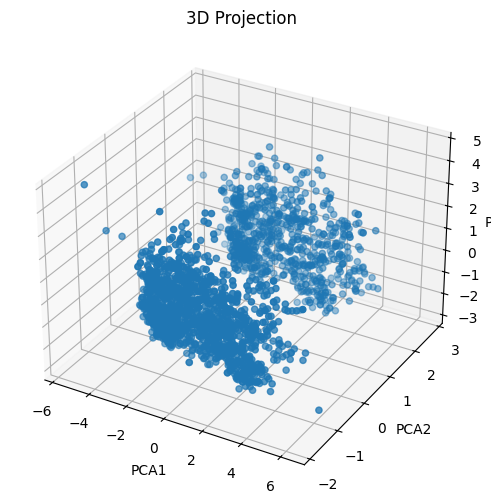

In [ ]:
#plot
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2])
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D Projection")

#Find K value:
1.Elbow method
2.Sihluate score

In [ ]:
!pip install kneed

In [ ]:

from sklearn.cluster import KMeans
from kneed import KneeLocator
wcss=[]
for k in range(1,11):
  kmeans=KMeans(n_clusters=k, random_state=42)
  kmeans.fit_predict(X_pca)
  wcss.append(kmeans.inertia_)

knee=KneeLocator(range(1,11),wcss, curve="convex",direction="decreasing")
print("Optimal k: ",knee.elbow)

Optimal k:  4


Text(0, 0.5, 'WCSS')

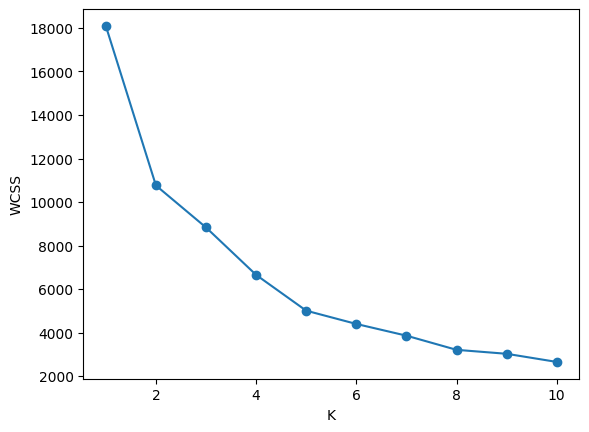

In [ ]:
#plot b/w K and WCSS
plt.plot(range(1,11),wcss, marker="o")
plt.xlabel("K")
plt.ylabel("WCSS")

In [ ]:
#Silhouatte score
from sklearn.metrics import silhouette_score
ss=[]
for k in range(2,11):
  kmeans=KMeans(n_clusters=k, random_state=42)
  labels=kmeans.fit_predict(X_pca)
  scores=silhouette_score(X_pca,labels)
  ss.append(scores)

Text(0, 0.5, 'Silhouette_score')

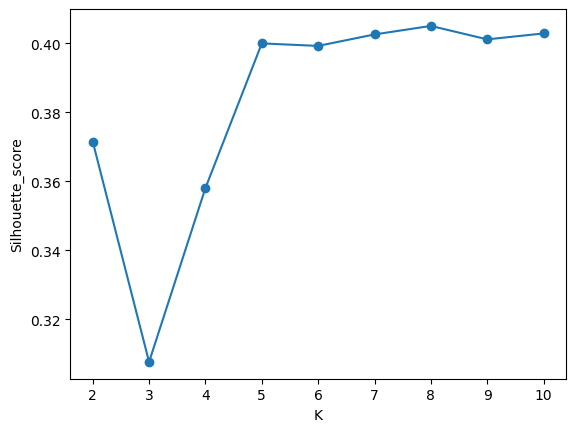

In [ ]:
#plot b/w K and SS
plt.plot(range(2,11),ss,marker='o')
plt.xlabel("K")
plt.ylabel("Silhouette_score")

Text(0, 0.5, 'SS')

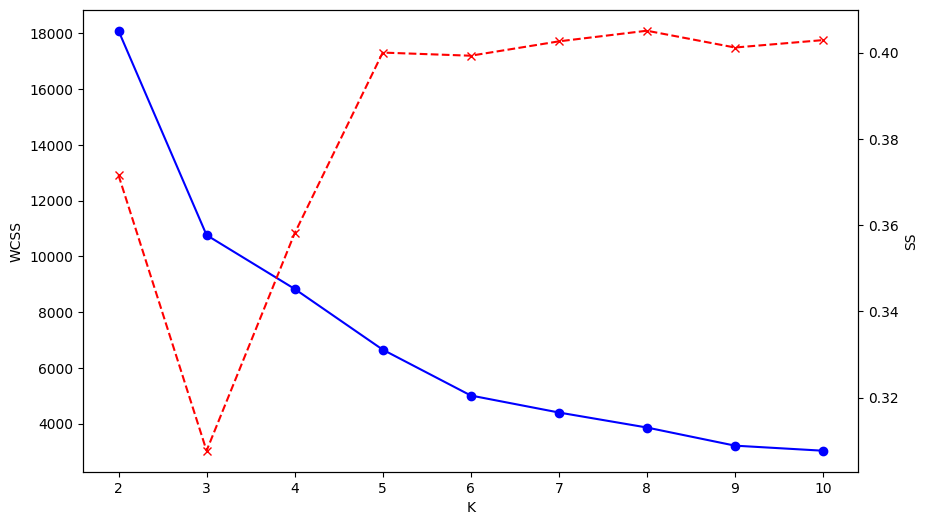

In [ ]:
#Combined Plot
k_range=range(2,11)
fig,ax1=plt.subplots(figsize=(10,6))
ax1.plot(k_range,wcss[:len(k_range)],color="blue",marker="o")
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2=ax1.twinx()
ax2.plot(k_range,ss[:len(k_range)],color="red",marker="x",linestyle="--")
ax2.set_ylabel("SS")

#Clustering


Text(0.5, 0.92, '3D projection')

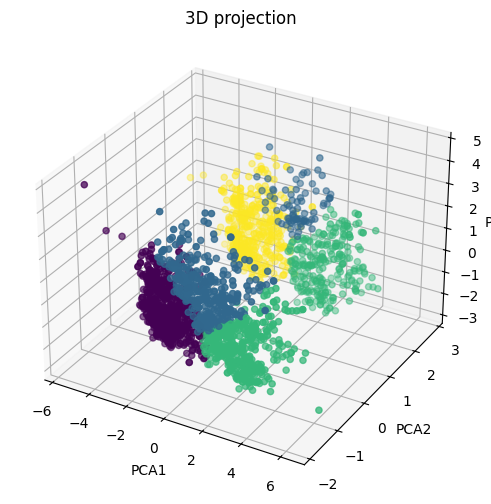

In [ ]:
from sklearn.cluster import KMeans

kmeans=KMeans(n_clusters=4, random_state=42)
labels=kmeans.fit_predict(X_pca)

fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels)
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D projection")

Text(0.5, 0.92, '3D projection')

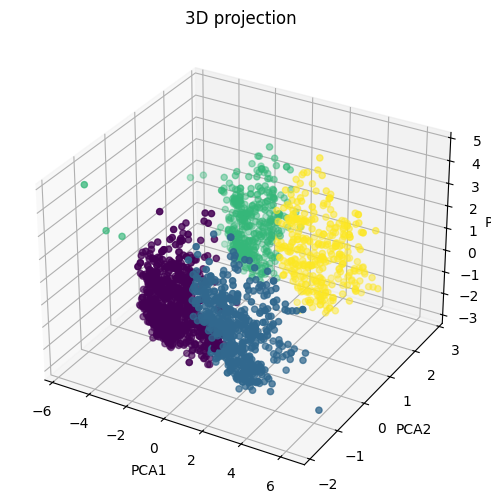

In [ ]:
#Agglomerative clustering
from sklearn.cluster import AgglomerativeClustering
agc=AgglomerativeClustering(n_clusters=4,linkage="ward")
labels_agg=agc.fit_predict(X_pca)


fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels_agg)
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D projection")

#Characterization of Clusters

In [ ]:

X["clusters"]=labels_agg


In [ ]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Costomer_tenure_days,Total_spending,Total_children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_with_Alone,Living_with_Partner,clusters
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='clusters', ylabel='count'>

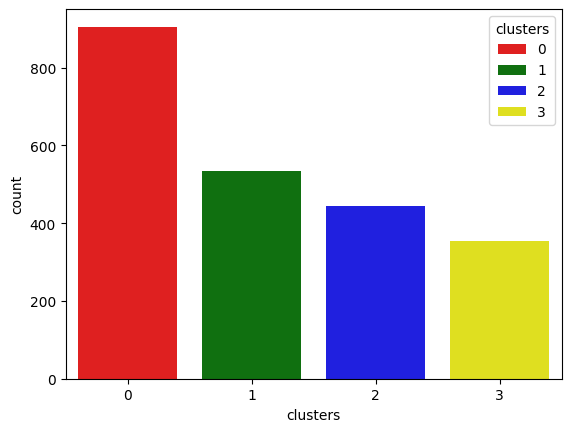

In [ ]:
#plot
pal=["red","green","blue","yellow"]
sns.countplot(x=X["clusters"], palette=pal, hue=X["clusters"])

<Axes: xlabel='Total_spending', ylabel='Income'>

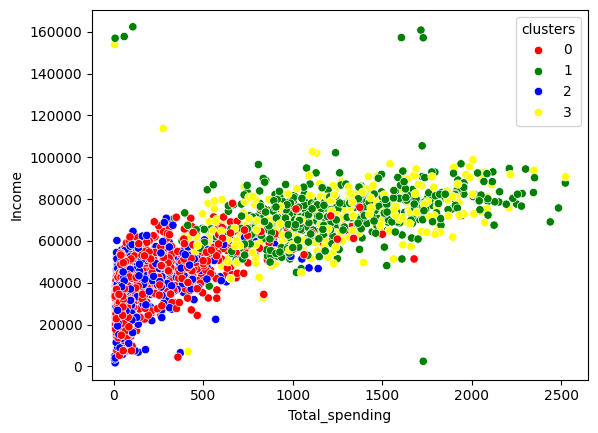

In [ ]:
#Income and Total spending
sns.scatterplot(x=X["Total_spending"],y=X["Income"], hue=X["clusters"], palette=pal)

In [ ]:
#Cluster summary
cluster_summary=X.groupby("clusters").mean()
print(cluster_summary)

                Income    Recency  NumDealsPurchases  NumWebPurchases  \
clusters                                                                
0         39680.580110  48.914917           2.594475         3.153591   
1         72808.445693  49.202247           1.958801         5.687266   
2         36960.143018  48.319820           2.594595         2.713964   
3         70722.681303  50.504249           1.855524         5.790368   

          NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
clusters                                                                        
0                    0.969061           4.143646           6.307182  0.011050   
1                    5.498127           8.659176           3.580524  0.005618   
2                    0.837838           3.623874           6.659910  0.011261   
3                    5.014164           8.430595           3.728045  0.005666   

          Response        Age  Costomer_tenure_days  Total_spending  \
clu